# Intuit Dome arena-store analysis

**Three Los Angeles Clippers home playoff games · April 24, April 26, and May 1, 2025**

This notebook answers a deliberately narrow question: **what does the supplied transaction data say about revenue mix, transaction economics, and timing?** It also makes the data limitations explicit.

Headline results:

- **$1.156M** in net sales across **31,346 transactions** and **16,835 purchasing accounts**.
- Food & beverage supplied **62.8%** of sales; retail supplied **37.1%**. Food & beverage sales were **69.1% higher** than retail—not 1.7% higher.
- The **final hour before scheduled tipoff** was the highest-revenue hour in all three games.
- Retail stores had the largest average transaction value (**$88.44**); mixed-format stores generated the most transactions (**25,274**).
- Store-entry and purchase identifiers do not overlap, so individual conversion cannot be calculated from this workbook.


## Reproducible setup

The notebook reads only the de-identified aggregates committed under `data/processed`. To regenerate those files from the private source workbook, run `python scripts/build_public_data.py --workbook /path/to/workbook.xlsx` from the project root.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

def find_project_root(start=Path.cwd()):
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "processed" / "headline_metrics.csv").exists():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the project directory.")

ROOT = find_project_root()
DATA = ROOT / "data" / "processed"
ASSETS = ROOT / "assets"

def read_table(name):
    return pd.read_csv(DATA / f"{name}.csv")

def show_asset(name):
    image = plt.imread(ASSETS / name)
    fig, ax = plt.subplots(figsize=(13, 6.6))
    ax.imshow(image)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

headline = read_table("headline_metrics").set_index("metric")
vertical = read_table("business_vertical_summary")
store_type = read_table("store_type_summary")
games = read_table("game_summary")
game_hour = read_table("game_hour_summary")
quality = read_table("data_quality_summary")

print(f"Project root: {ROOT}")
print(f"Loaded {len(list(DATA.glob('*.csv')))} aggregate tables.")


Project root: /workspace/scratch/eed034dc870d/intuit-dome-analysis-2025-revised
Loaded 15 aggregate tables.


## Metric definitions

| Metric | Definition |
|---|---|
| Net sales | Sum of the source `NetAmount` field; no margin or cost data were supplied |
| Transaction | Unique `TransactionId` within a game, after aggregating its line items |
| Average transaction value | Net sales ÷ unique transactions—not mean line-item value |
| Attributable transaction | A transaction containing at least one line from the named business vertical |
| Customer | Unique purchasing `CustomerAccount` in the three-game window |
| Store-entry event | One StoreEntries row; repeated rows for the same person are not treated as additional attendees |


## Validation before interpretation


In [2]:
checks = {
    "net sales reconcile": round(float(headline.loc["net_sales", "value"]), 2) == 1_155_790.74,
    "transaction count": int(headline.loc["transactions", "value"]) == 31_346,
    "sales store mapping": int(quality.loc[quality["metric"] == "Sales rows mapped to a store", "value"].iloc[0]) == 60_369,
    "no negative net rows": int(quality.loc[quality["metric"] == "Negative-net line rows", "value"].iloc[0]) == 0,
    "conversion linkage unavailable": quality.loc[quality["metric"] == "Store-entry IDs present in CustomerIDs", "status"].iloc[0] == "Blocker",
}
assert all(checks.values()), checks
print(pd.Series(checks, name="passed").to_string())
print("\nAll required validation checks passed.")


net sales reconcile               True
transaction count                 True
sales store mapping               True
no negative net rows              True
conversion linkage unavailable    True

All required validation checks passed.


In [3]:
review_items = quality.loc[quality["status"].isin(["Review", "Blocker"]), ["area", "metric", "value", "status", "note"]]
print(review_items.to_string(index=False))


         area                                                metric        value  status                                                                 note
        Sales                     Exact duplicate-looking line rows    94.000000  Review           No line ID is available, so these are flagged and retained
        Sales                                    Zero-net line rows  1169.000000  Review        Retained; may reflect complimentary or fully discounted items
      Mapping                              Store-entry mapping rate     0.896634  Review                         Two checkpoint labels have no StoreNames row
      Mapping                           Unmapped store-entry events  5088.000000  Review                               D'USSÉ Cognac Club and Club Grey Goose
Store entries                                     Missing entry IDs  3549.000000  Review             Missing IDs are excluded from repeat-person calculations
Store entries Repeat identified events beyond first 

## 1. Revenue mix

Food & beverage generated **$725,426**, compared with **$428,929.50** for retail and **$1,435.24** for service items. The ratio is **1.69×**, equivalent to food & beverage being **69.1% higher** than retail.

In mixed-format stores specifically, food & beverage supplied **99.1%** of net sales. That result describes the merchandise mix in those locations; it does not say mixed stores outperform standalone retail overall.


In [4]:
display_vertical = vertical[["business_vertical", "net_sales", "sales_share", "attributable_transactions", "average_attributable_transaction"]].copy()
display_vertical["sales_share"] = display_vertical["sales_share"].map(lambda value: f"{value:.1%}")
display_vertical["net_sales"] = display_vertical["net_sales"].map(lambda value: f"${value:,.2f}")
display_vertical["average_attributable_transaction"] = display_vertical["average_attributable_transaction"].map(lambda value: f"${value:,.2f}")
print(display_vertical.to_string(index=False))


business_vertical   net_sales sales_share  attributable_transactions average_attributable_transaction
Food And Beverage $725,426.00       62.8%                      26421                           $27.46
           Retail $428,929.50       37.1%                       5255                           $81.62
    Service Items   $1,435.24        0.1%                        282                            $5.09


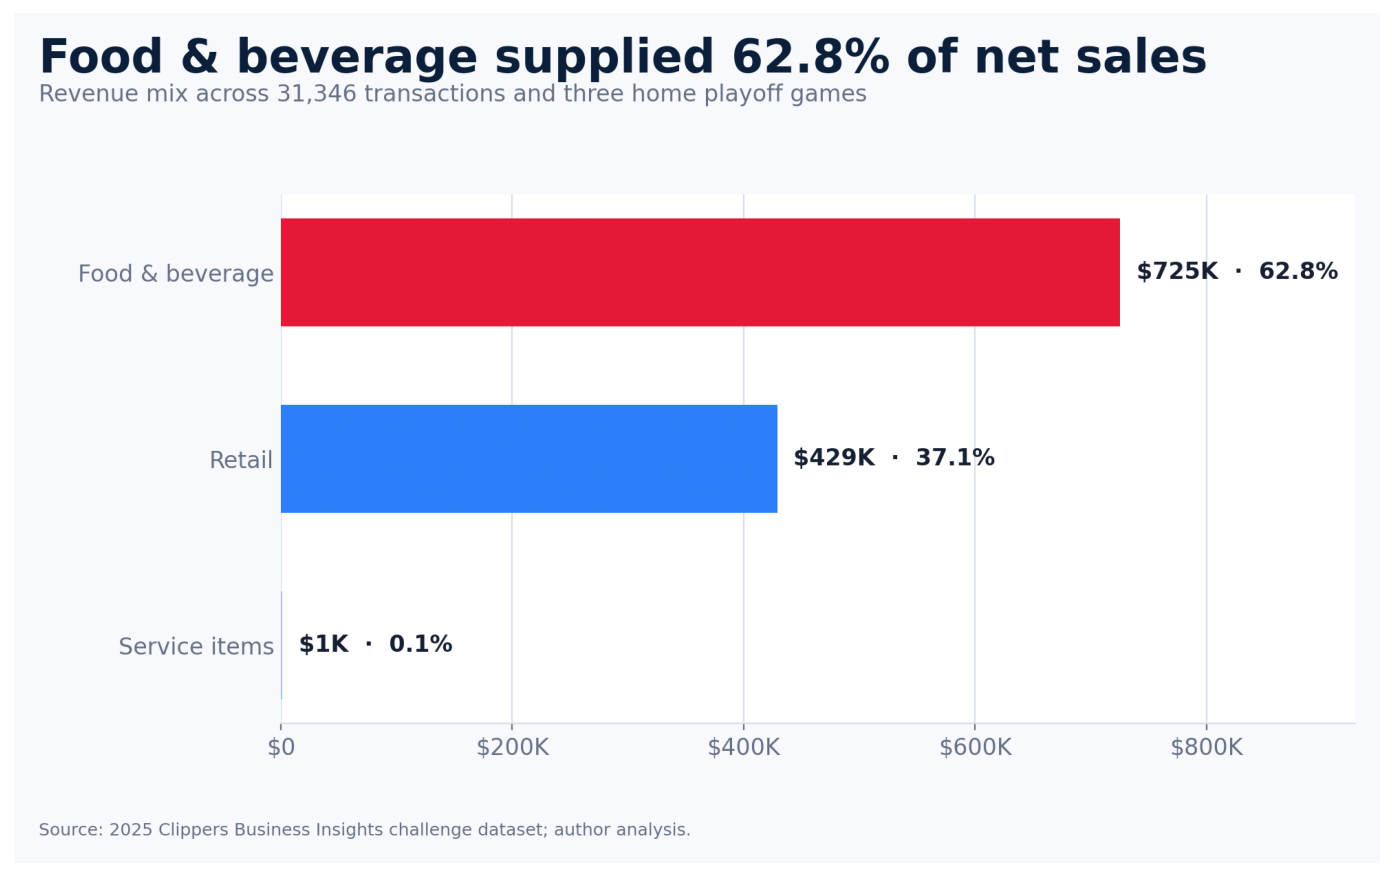

In [5]:
show_asset("revenue_mix.png")


## 2. Volume and ticket tell different stories

Mixed-format stores handled **80.6% of transactions** and produced **59.9% of sales**, with a **$27.38** average transaction. Standalone retail had far fewer transactions but a much larger **$88.44** average ticket. These are complementary economics, not an ordinal “best store type” ranking.


In [6]:
display_store_type = store_type[["store_type", "net_sales", "transactions", "average_transaction_value", "sales_share"]].copy()
display_store_type["net_sales"] = display_store_type["net_sales"].map(lambda value: f"${value:,.2f}")
display_store_type["average_transaction_value"] = display_store_type["average_transaction_value"].map(lambda value: f"${value:,.2f}")
display_store_type["sales_share"] = display_store_type["sales_share"].map(lambda value: f"{value:.1%}")
print(display_store_type.to_string(index=False))


          store_type   net_sales  transactions average_transaction_value sales_share
Concessions & Retail $691,902.16         25274                    $27.38       59.9%
              Retail $423,616.25          4790                    $88.44       36.7%
         Concessions  $40,272.33          1282                    $31.41        3.5%


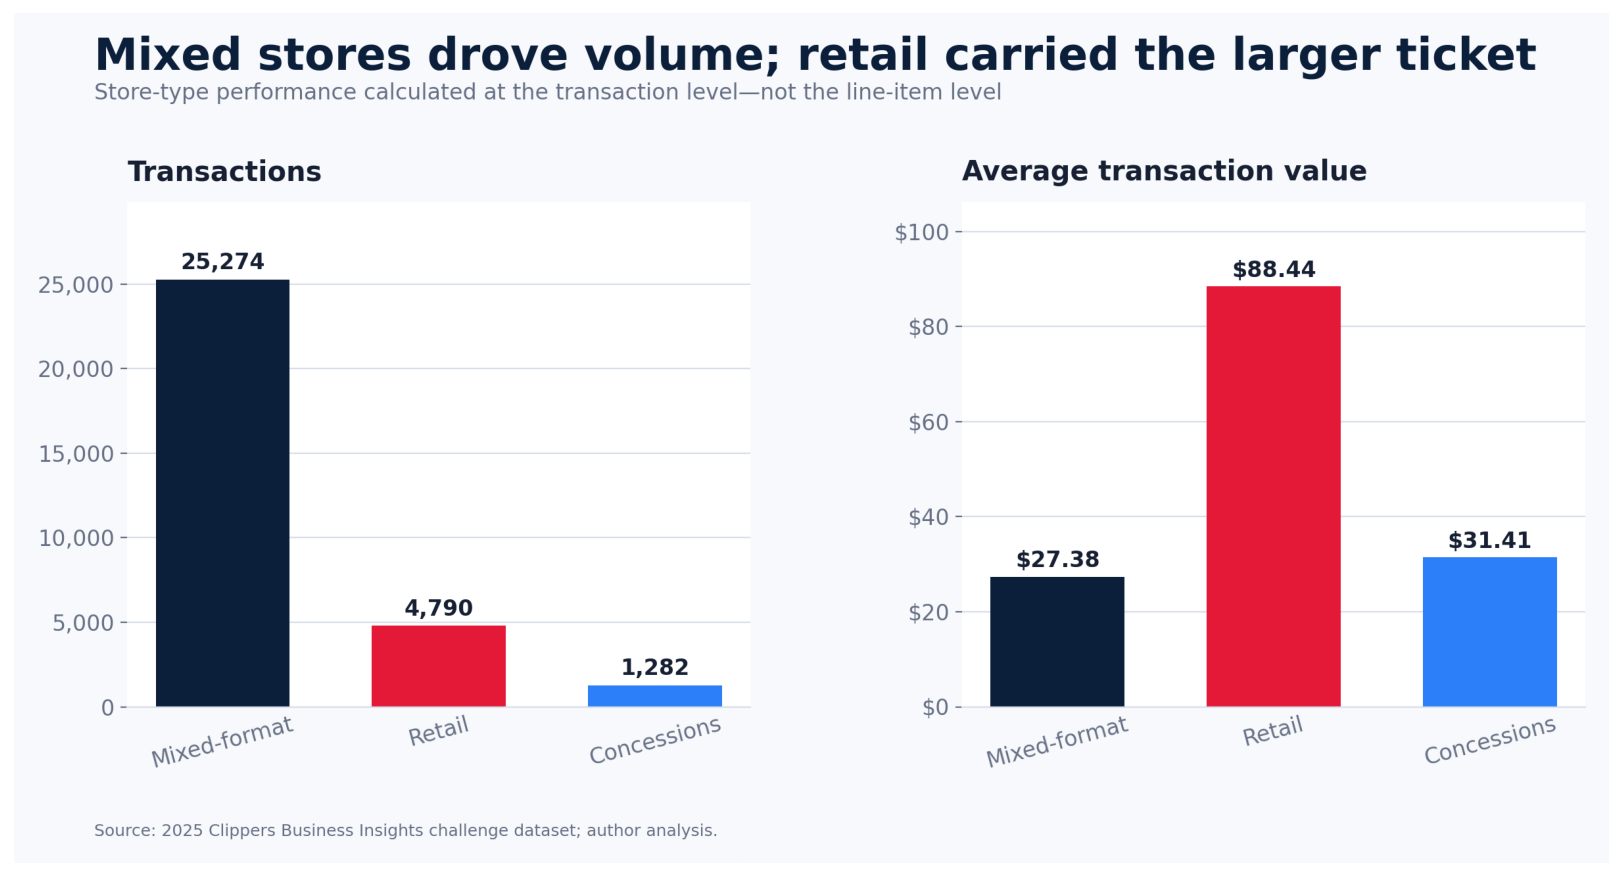

In [7]:
show_asset("store_type_economics.png")


## 3. Timing must be normalized to tipoff

Absolute clock time is misleading because the April 26 game started at 3:00 PM while the other two started at 7:00 PM. Relative to each scheduled tipoff, hour **−1**—the final hour beforehand—was the revenue peak in all three games. It supplied **34.0%**, **35.6%**, and **27.6%** of each game's net sales, respectively.

Transaction count also peaked in hour −1 for Games 3 and 4, but in hour +1 for Game 6. That distinction is why the chart and recommendation use *revenue peak*, not a blanket traffic claim.


In [8]:
sales_peaks = game_hour.loc[game_hour.groupby("game_date")["net_sales"].idxmax(), ["game_label", "relative_hour", "net_sales", "transactions"]]
transaction_peaks = game_hour.loc[game_hour.groupby("game_date")["transactions"].idxmax(), ["game_label", "relative_hour", "net_sales", "transactions"]]
pregame = game_hour.loc[game_hour["relative_hour"] == -1, ["game_date", "game_label", "net_sales"]].merge(games[["game_date", "net_sales"]], on="game_date", suffixes=("_pregame", "_game"))
pregame["share_of_game_sales"] = pregame["net_sales_pregame"] / pregame["net_sales_game"]
print("Revenue peak by game")
print(sales_peaks.to_string(index=False))
print("\nTransaction-count peak by game")
print(transaction_peaks.to_string(index=False))
print("\nFinal pregame hour share")
print(pregame[["game_label", "share_of_game_sales"]].assign(share_of_game_sales=lambda d: d["share_of_game_sales"].map(lambda value: f"{value:.1%}")).to_string(index=False))


Revenue peak by game
     game_label  relative_hour  net_sales  transactions
Game 3 · Apr 24             -1  147462.35          4015
Game 4 · Apr 26             -1  137713.63          3716
 Game 6 · May 1             -1   92538.17          2861

Transaction-count peak by game
     game_label  relative_hour  net_sales  transactions
Game 3 · Apr 24             -1  147462.35          4015
Game 4 · Apr 26             -1  137713.63          3716
 Game 6 · May 1              1   86953.94          3052

Final pregame hour share
     game_label share_of_game_sales
Game 3 · Apr 24               34.0%
Game 4 · Apr 26               35.6%
 Game 6 · May 1               27.6%


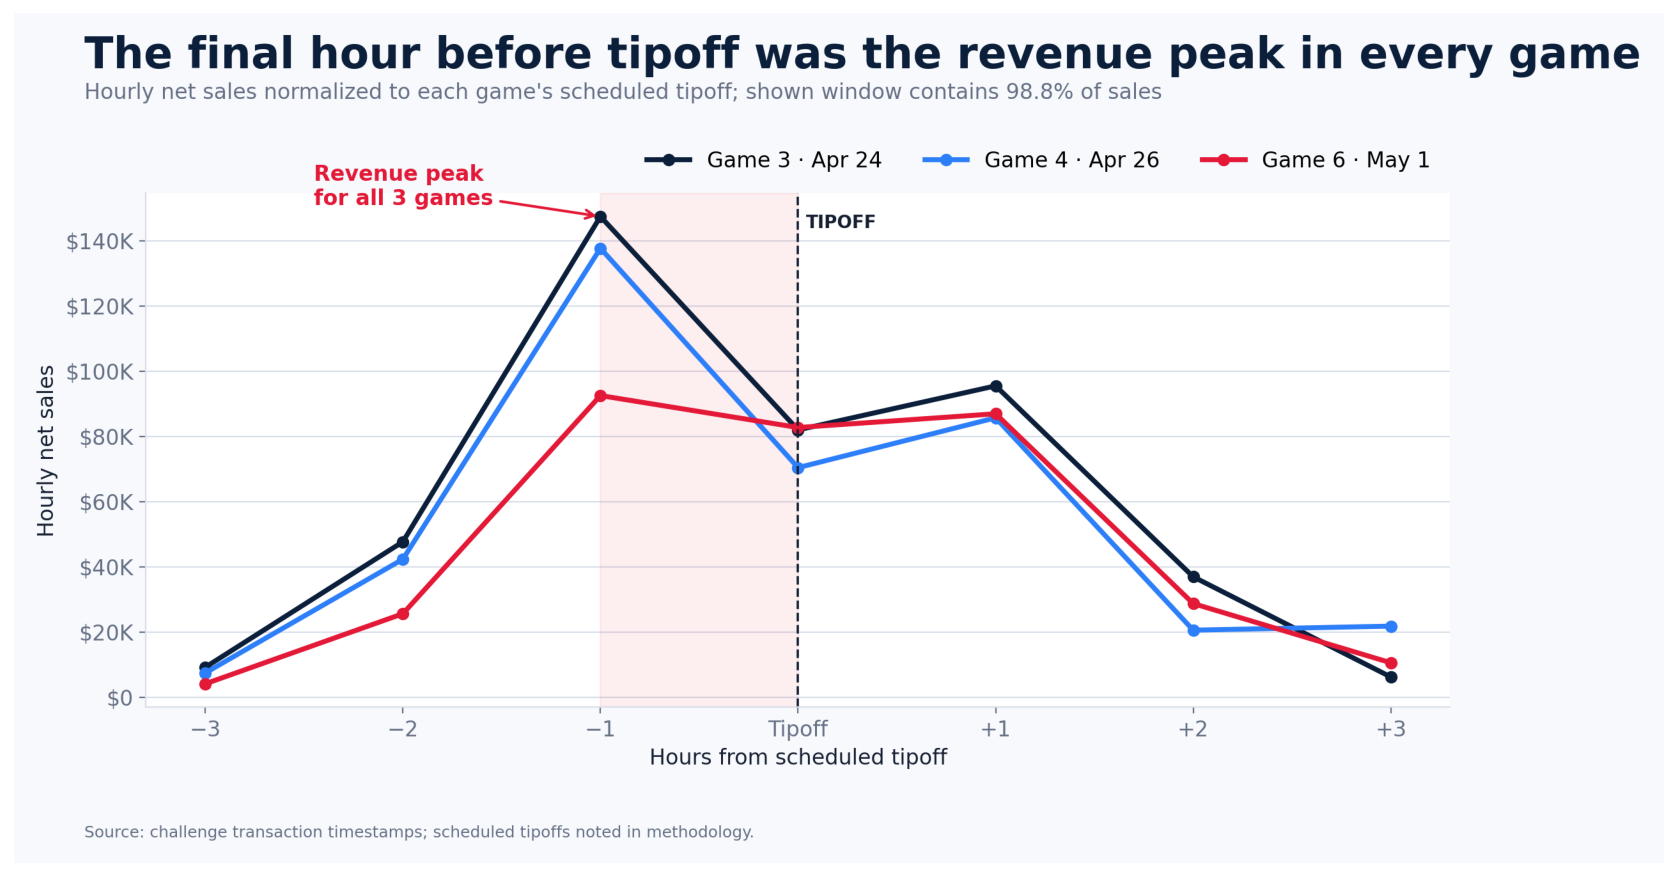

In [9]:
show_asset("sales_relative_to_tipoff.png")


## 4. Performance declined across the three games

Net sales fell from **$433,679** in Game 3 to **$334,777** in Game 6, a **22.8% decline**. Transactions fell **13.7%**, and average transaction value fell from **$38.66** to **$34.57** (**10.6%**). The dataset does not contain attendance, inventory, queue, staffing, promotion, or availability fields, so it cannot isolate the cause.


In [10]:
display_games = games[["game_label", "net_sales", "transactions", "customers", "average_transaction_value", "median_transaction_value"]].copy()
display_games["net_sales"] = display_games["net_sales"].map(lambda value: f"${value:,.2f}")
for column in ["average_transaction_value", "median_transaction_value"]:
    display_games[column] = display_games[column].map(lambda value: f"${value:,.2f}")
print(display_games.to_string(index=False))


     game_label   net_sales  transactions  customers average_transaction_value median_transaction_value
Game 3 · Apr 24 $433,679.02         11218       6584                    $38.66                   $27.50
Game 4 · Apr 26 $387,335.12         10444       6384                    $37.09                   $25.00
 Game 6 · May 1 $334,776.60          9684       5811                    $34.57                   $25.00


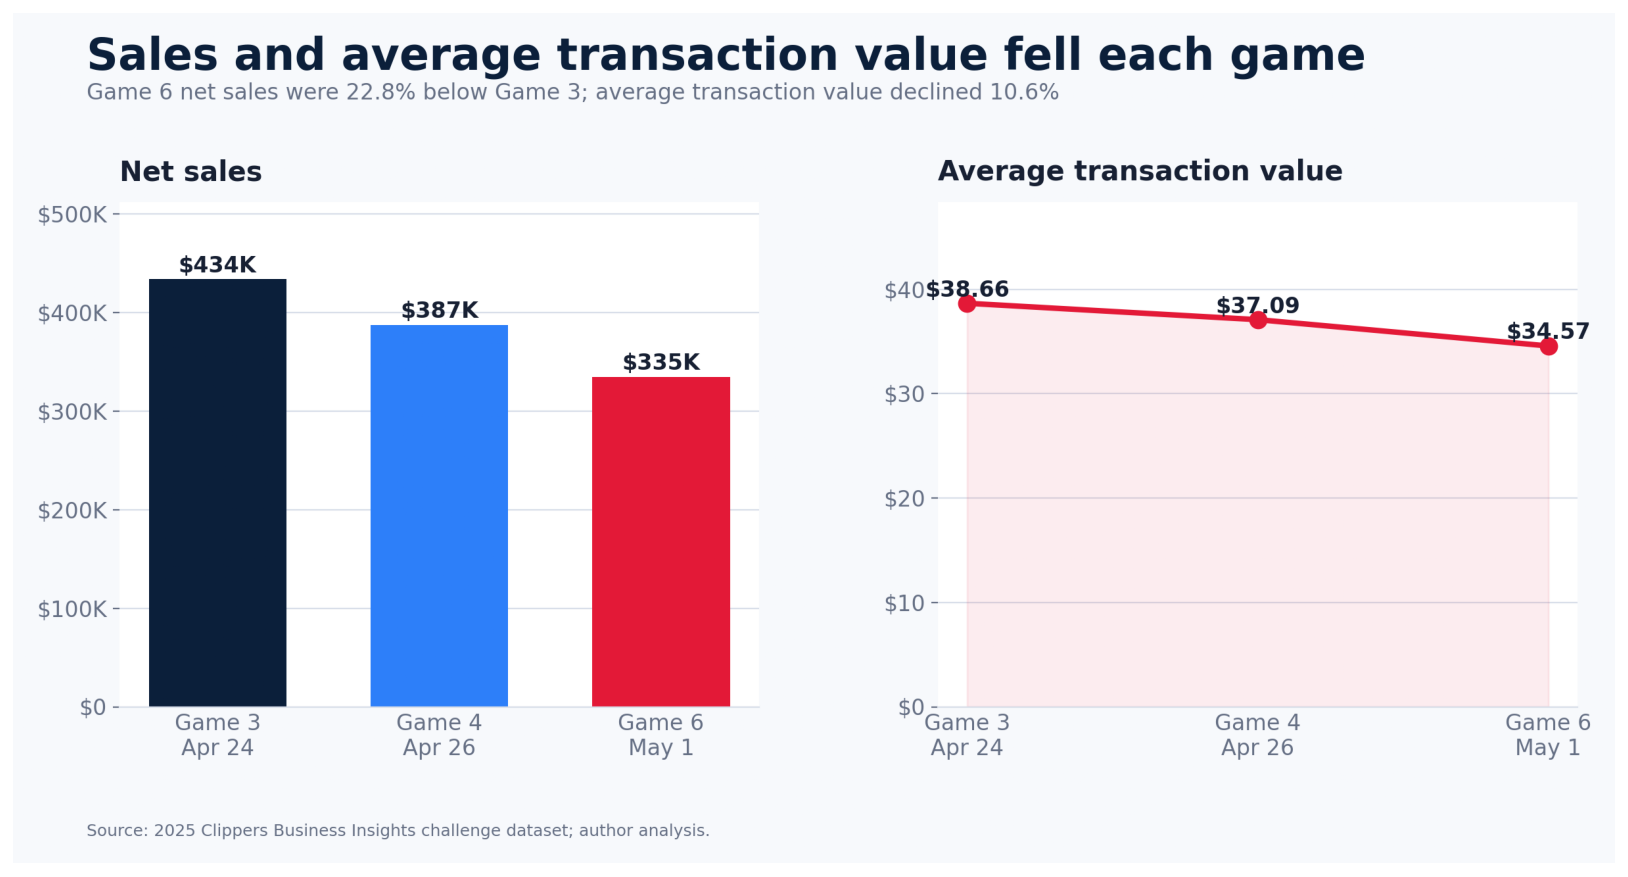

In [11]:
show_asset("game_trend.png")


## 5. Repeat-purchaser signal

Only **323 accounts (1.9%)** purchased in all three games, yet they supplied **13.5%** of net sales. This is descriptive—not a causal loyalty result—and it may include differences in party size, ticket ownership, or account sharing that the source data cannot resolve.


In [12]:
frequency = read_table("customer_frequency_summary")
display_frequency = frequency.copy()
display_frequency["net_sales"] = display_frequency["net_sales"].map(lambda value: f"${value:,.2f}")
display_frequency["average_customer_spend"] = display_frequency["average_customer_spend"].map(lambda value: f"${value:,.2f}")
display_frequency["median_customer_spend"] = display_frequency["median_customer_spend"].map(lambda value: f"${value:,.2f}")
display_frequency["customer_share"] = display_frequency["customer_share"].map(lambda value: f"{value:.1%}")
display_frequency["sales_share"] = display_frequency["sales_share"].map(lambda value: f"{value:.1%}")
print(display_frequency.to_string(index=False))


 games_purchased  customers   net_sales average_customer_spend median_customer_spend  average_transactions customer_share sales_share
               1      15214 $859,265.61                 $56.48                $36.00              1.510319          90.4%       74.3%
               2       1298 $140,981.72                $108.61                $75.00              3.271957           7.7%       12.2%
               3        323 $155,543.41                $481.56               $132.25             12.758514           1.9%       13.5%


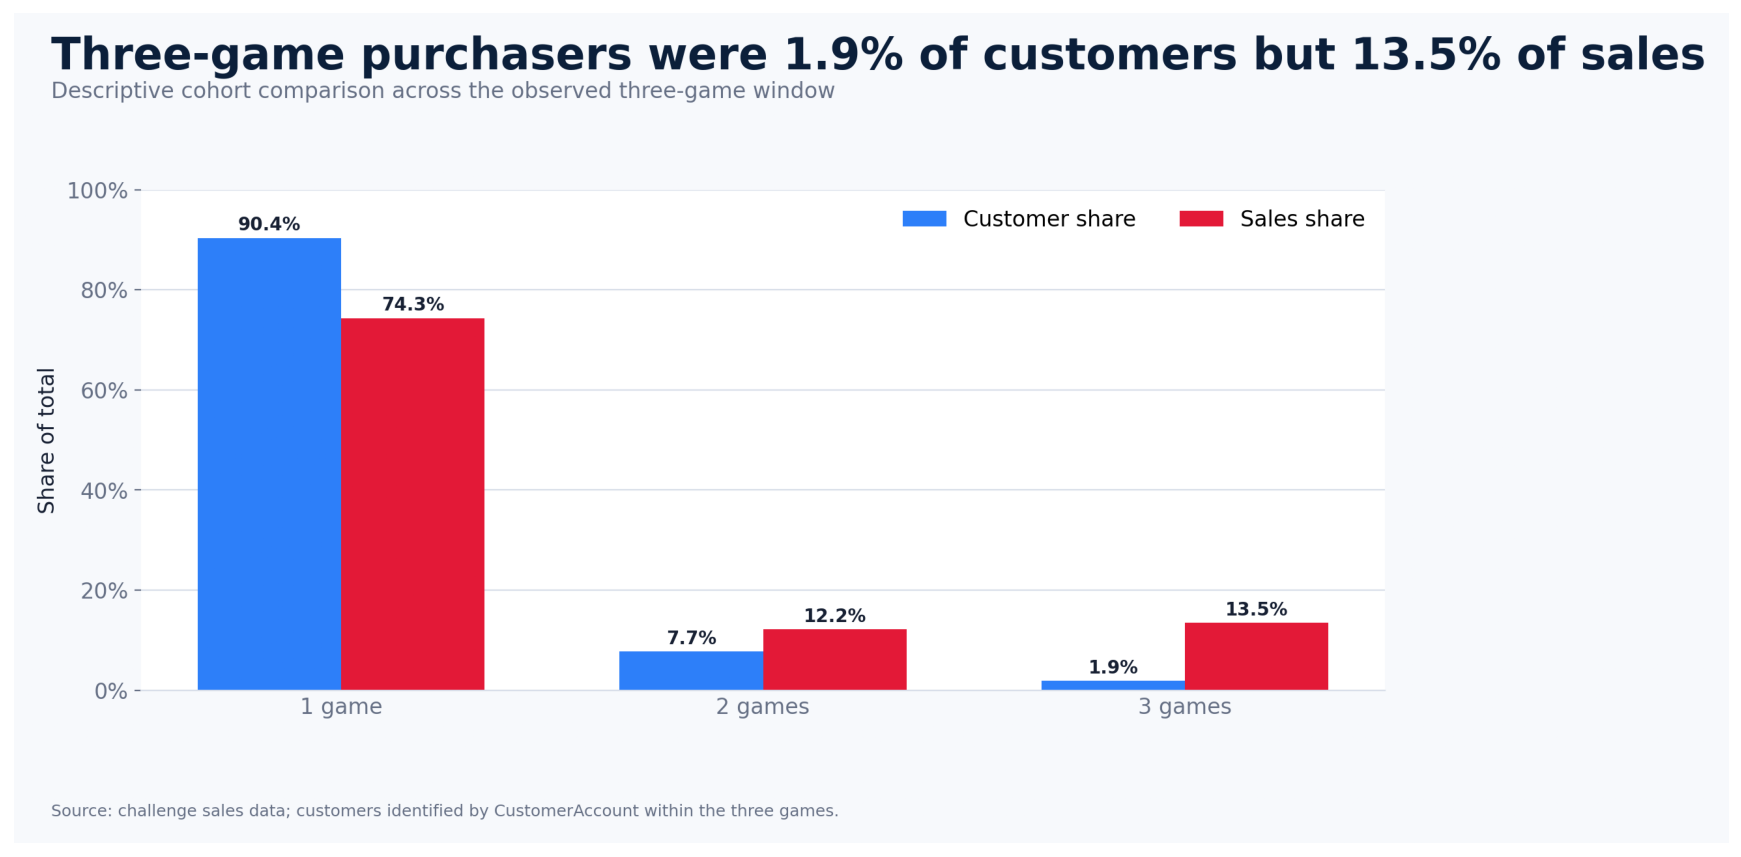

In [13]:
show_asset("customer_frequency.png")


## 6. Foot traffic is context, not conversion

The StoreEntries worksheets contain **49,223 entry events** from **20,603 unique IDs**. Among events with an ID, **22,468 are repeats** beyond the first event per person/game; another **3,549 events have no ID**. Row count is therefore not attendance. Store mapping covers **89.7%** of events; the remaining 5,088 events belong to two checkpoints absent from `StoreNames`.

Most importantly, StoreEntries `NBAId` values have **zero overlap** with `CustomerIDs.NBAId`; the same is true for the arena `EntryScans` IDs. Therefore this analysis does **not** calculate visitor-to-purchaser conversion, purchase attribution after entry, or customer movement paths.


In [14]:
entries = read_table("store_entry_summary")
unmatched = read_table("unmatched_entry_checkpoints")
print(entries.to_string(index=False))
print("\nUnmapped checkpoints")
print(unmatched.to_string(index=False))


 game_date      game_label  entry_events  unique_entry_ids  missing_entry_ids  mapped_entry_events  repeat_entry_events  store_mapping_rate
2025-04-24 Game 3 · Apr 24         17536              8099               1183                15981                 8254            0.911325
2025-04-26 Game 4 · Apr 26         16332              7834                848                14764                 7650            0.903992
2025-05-01  Game 6 · May 1         15355              7273               1518                13390                 6564            0.872029

Unmapped checkpoints
   checkpoint_name  entry_events  games_observed
D'USSÉ Cognac Club          2617               3
   Club Grey Goose          2471               3


## Recommendations framed as tests

1. **Protect the final pregame hour.** Pilot incremental staffing, replenishment, and queue-management coverage in hour −1. Predefine outcomes such as revenue per minute, service time, abandonment, and out-of-stock rate.
2. **Test attach offers without assuming conversion.** Retail carries a high ticket but low volume; test merchandise-plus-concessions prompts or member offers using randomized or phased rollout and an auditable exposure key.
3. **Diagnose the game-to-game decline.** Add attendance, open-store minutes, SKU availability, promotions, staffing, and queue measures before assigning a cause to the 22.8% sales decline.
4. **Repair the measurement layer.** Supply a stable crosswalk between entry and purchase identifiers, add the two missing checkpoint mappings, and define whether an entry row is a scan, threshold crossing, or session event.

## Limitations

- Three games from one playoff series are a small, non-random sample; results should not be generalized to a full season without validation.
- Net sales are not profit. Costs, margin, labor, inventory, refunds, taxes, and payment failures are unavailable.
- Ninety-four line rows are exact duplicate-looking records, but no source line ID exists; they are flagged and retained rather than silently removed.
- There are 1,169 zero-net line rows and 578 zero-net transactions; they remain in counts and are disclosed.
- Scheduled tipoff anchors are 7:00 PM (Apr 24), 3:00 PM (Apr 26), and 7:00 PM (May 1). Official game durations were 2:19, 2:30, and 2:13, respectively.

Official duration references: [Apr 24 NBA book](https://statsdmz.nba.com/pdfs/20250424/20250424_DENLAC.pdf), [Apr 26 NBA book](https://statsdmz.nba.com/pdfs/20250426/20250426_DENLAC.pdf), and [May 1 NBA book](https://statsdmz.nba.com/pdfs/20250501/20250501_DENLAC.pdf).
